# EE 451: Communications Systems
## Lesson 5 - Amplitude Modulation Theory

### Learning Objectives
By the end of this lesson, you will be able to:
- Explain the need for modulation in wireless communication systems
- Derive and analyze Double Sideband Suppressed Carrier (DSB-SC) modulation
- Analyze Full Carrier AM and calculate modulation index
- Identify and explain overmodulation and its spectral consequences
- Design and analyze envelope detectors for AM demodulation
- Calculate power efficiency for DSB-SC and full carrier AM

### Textbook Reference
Haykin & Moher, Chapter 3.1-3.3

In [1]:
# Setup: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

print("Setup complete! NumPy version:", np.__version__)

Setup complete! NumPy version: 2.4.1


## 1. Why Modulation?

**Problem 1: Antenna size**
- Efficient antenna length ≈ λ/4 = c/(4f)
- Voice signal: 300-3400 Hz → λ ≈ 100 km (impractical!)
- Solution: Shift to higher frequency (RF carrier)

**Problem 2: Frequency division multiplexing**
- Multiple users/channels sharing spectrum

**Problem 3: Propagation characteristics**
- Different frequencies have different propagation properties

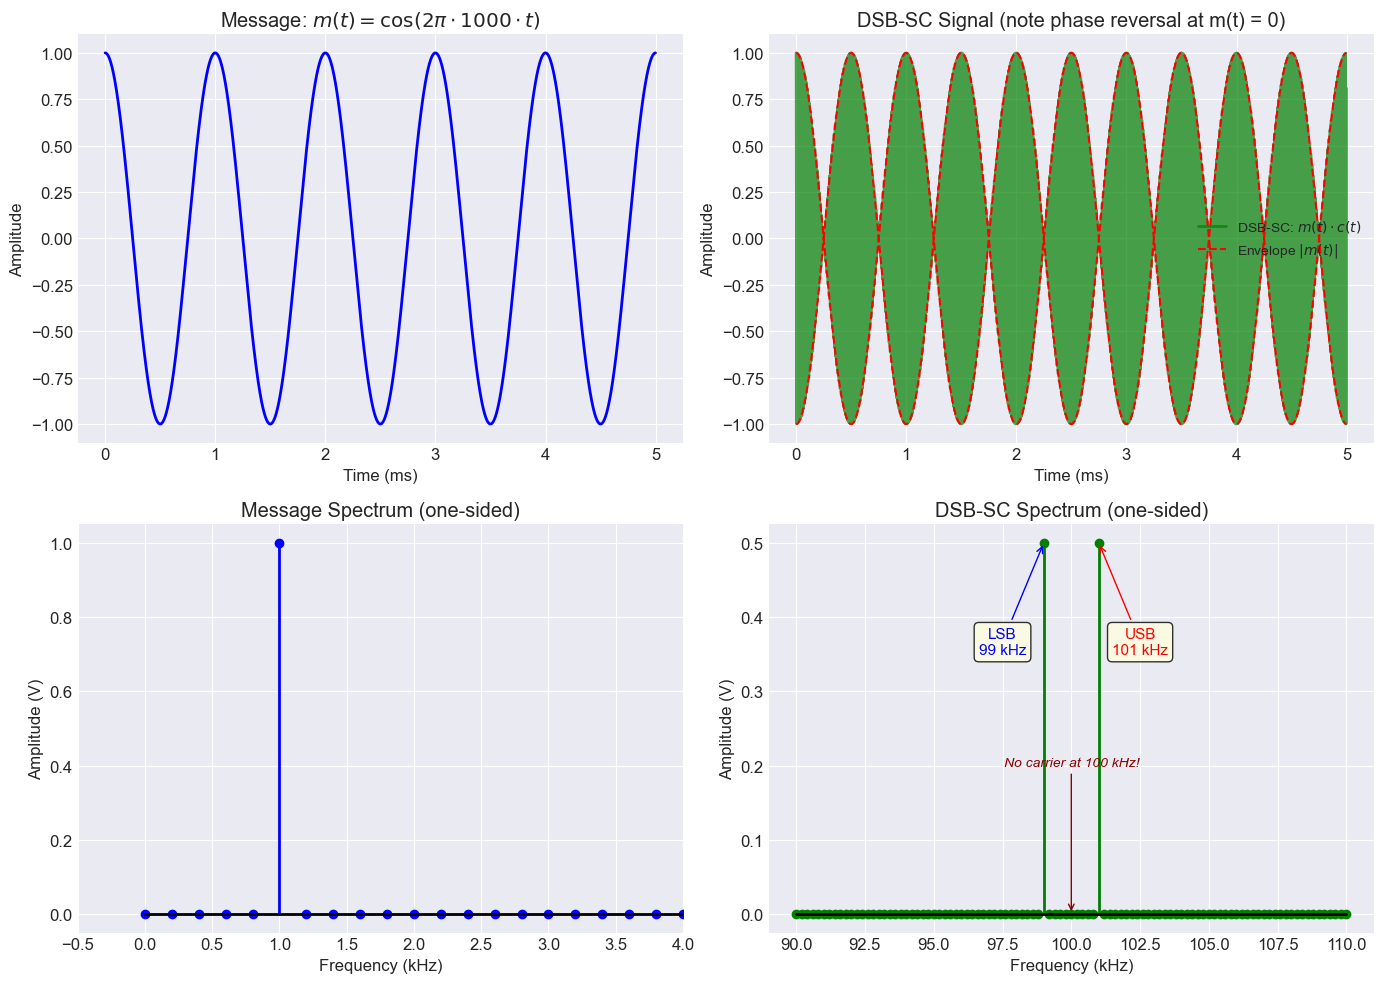

DSB-SC Worked Example:
  m(t) = cos(2π·1000 t),  c(t) = cos(2π·100000 t)
  s(t) = cos(2π·1000t) · cos(2π·100000t)
       = ½[cos(2π·99000t) + cos(2π·101000t)]
  → LSB at 99 kHz, USB at 101 kHz
  → No component at carrier frequency 100 kHz (suppressed)
  → Bandwidth = 2·fm = 2 kHz


In [2]:
# =============================================================================
# Section 1: DSB-SC — Time and Frequency Domain
# =============================================================================
# Worked Example 1: Single-tone DSB-SC
fm = 1000     # Message frequency (Hz)
fc = 100000   # Carrier frequency (Hz)
Ac = 1        # Carrier amplitude

# Time domain
fs = 10 * fc  # Sampling rate
T = 0.005     # Duration (5 ms = 5 message cycles)
t = np.linspace(0, T, int(fs * T), endpoint=False)

m = np.cos(2 * np.pi * fm * t)
c = Ac * np.cos(2 * np.pi * fc * t)
s_dsb = m * c

# Frequency domain via FFT (normalized to show actual amplitudes)
N = len(t)
dt = t[1] - t[0]
S = fft(s_dsb) * dt
freqs = fftfreq(N, dt)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time domain: message
axes[0, 0].plot(t * 1000, m, 'b-')
axes[0, 0].set_title(f'Message: $m(t) = \\cos(2\\pi \\cdot {fm} \\cdot t)$')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_xlabel('Time (ms)')

# Time domain: DSB-SC with envelope
axes[0, 1].plot(t * 1000, s_dsb, 'g-', alpha=0.7, label='DSB-SC: $m(t) \\cdot c(t)$')
axes[0, 1].plot(t * 1000, np.abs(m), 'r--', linewidth=1.5, label='Envelope $|m(t)|$')
axes[0, 1].plot(t * 1000, -np.abs(m), 'r--', linewidth=1.5)
axes[0, 1].set_title('DSB-SC Signal (note phase reversal at m(t) = 0)')
axes[0, 1].set_xlabel('Time (ms)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].legend(fontsize=10)

# Frequency domain: message spectrum (one-sided, normalized by T for true amplitude)
M = fft(m) * dt
pos_mask_m = (freqs >= 0) & (freqs <= 5000)
axes[1, 0].stem(freqs[pos_mask_m] / 1000, 2 * np.abs(M[pos_mask_m]) / T,
                linefmt='b-', markerfmt='bo', basefmt='k-')
axes[1, 0].set_title('Message Spectrum (one-sided)')
axes[1, 0].set_xlabel('Frequency (kHz)')
axes[1, 0].set_ylabel('Amplitude (V)')
axes[1, 0].set_xlim(-0.5, 4)

# Frequency domain: DSB-SC spectrum (one-sided, normalized by T for true amplitude)
pos_mask = (freqs >= 90000) & (freqs <= 110000)
S_onesided = 2 * np.abs(S[pos_mask]) / T
axes[1, 1].stem(freqs[pos_mask] / 1000, S_onesided,
                linefmt='g-', markerfmt='go', basefmt='k-')
axes[1, 1].set_title('DSB-SC Spectrum (one-sided)')
axes[1, 1].set_xlabel('Frequency (kHz)')
axes[1, 1].set_ylabel('Amplitude (V)')

# Find actual peak height for annotation placement
peak_val = S_onesided.max()

axes[1, 1].annotate('LSB\n99 kHz', xy=(99, peak_val), xytext=(97.5, peak_val * 0.7),
                    fontsize=11, ha='center', color='blue',
                    arrowprops=dict(arrowstyle='->', color='blue'),
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 1].annotate('USB\n101 kHz', xy=(101, peak_val), xytext=(102.5, peak_val * 0.7),
                    fontsize=11, ha='center', color='red',
                    arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 1].annotate('No carrier at 100 kHz!', xy=(100, 0), xytext=(100, peak_val * 0.4),
                    fontsize=10, ha='center', color='darkred', style='italic',
                    arrowprops=dict(arrowstyle='->', color='darkred'))

plt.tight_layout()
plt.show()

# Analytical verification
print("DSB-SC Worked Example:")
print(f"  m(t) = cos(2π·{fm} t),  c(t) = cos(2π·{fc} t)")
print(f"  s(t) = cos(2π·{fm}t) · cos(2π·{fc}t)")
print(f"       = ½[cos(2π·{fc-fm}t) + cos(2π·{fc+fm}t)]")
print(f"  → LSB at {(fc-fm)/1000:.0f} kHz, USB at {(fc+fm)/1000:.0f} kHz")
print(f"  → No component at carrier frequency {fc/1000:.0f} kHz (suppressed)")
print(f"  → Bandwidth = 2·fm = {2*fm/1000:.0f} kHz")

## 2. Full Carrier AM

**Standard AM formulation:**

$$s(t) = A_c\,[1 + \mu \cdot m_n(t)]\,\cos(2\pi f_c t)$$

where:
- $A_c$ = carrier amplitude
- $\mu$ = modulation index (typically $0 < \mu \leq 1$)
- $m_n(t)$ = normalized message signal with $|m_n(t)| \leq 1$

**Spectrum (single-tone case with $m_n(t) = \cos(2\pi f_m t)$):**
- Carrier at $f_c$: amplitude $A_c$
- LSB at $f_c - f_m$: amplitude $\mu A_c / 2$
- USB at $f_c + f_m$: amplitude $\mu A_c / 2$
- Bandwidth = $2f_m$ (same as DSB-SC)

**Key difference from DSB-SC:** The carrier is present, enabling simple envelope detection.

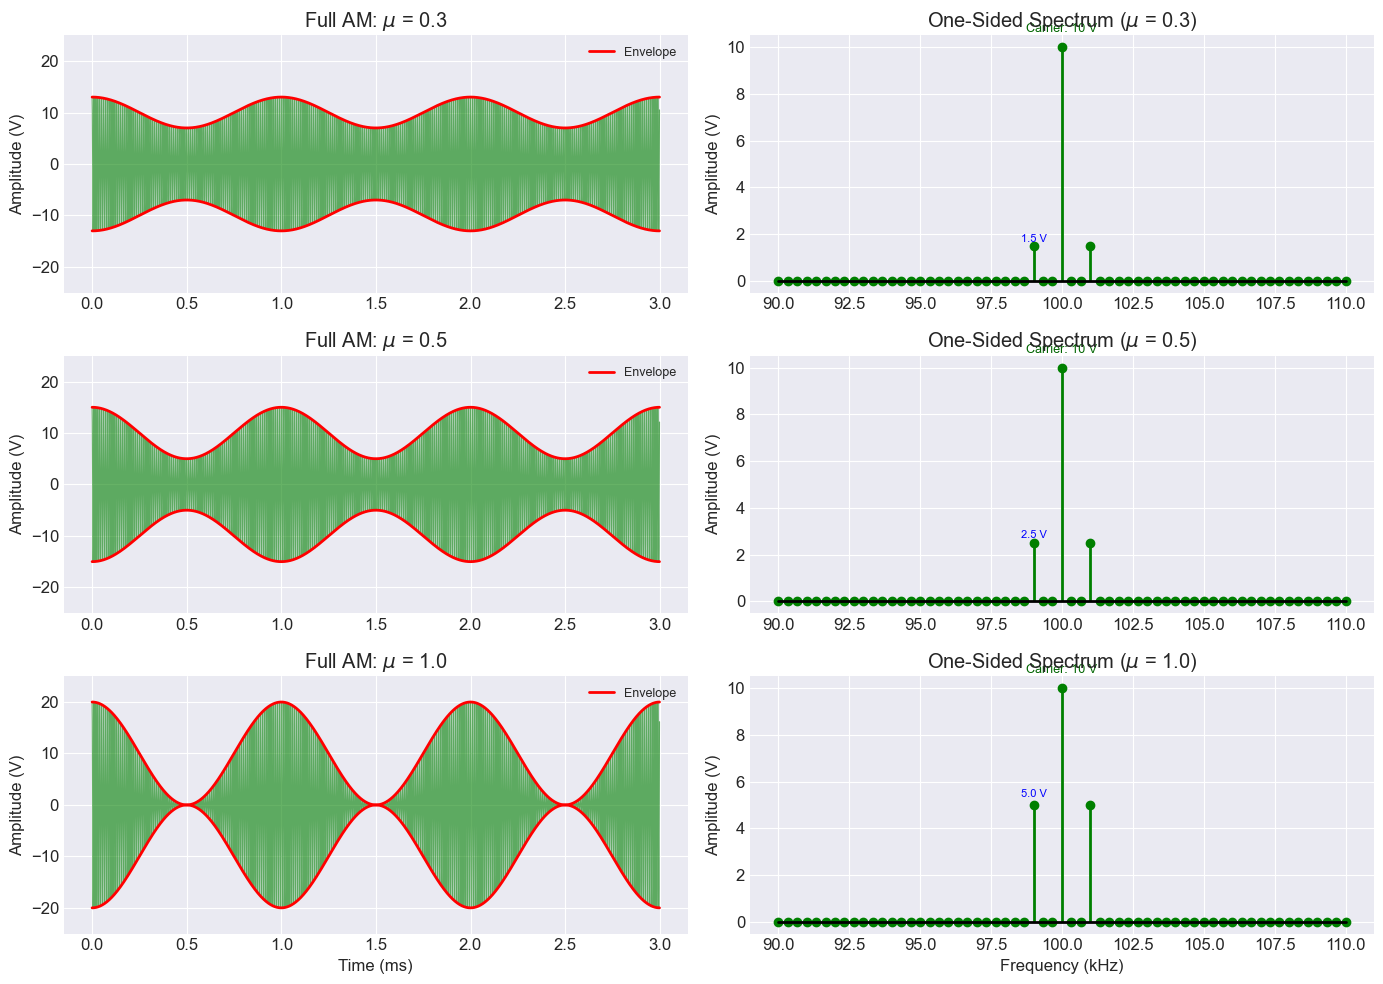

Worked Example 2: Single-Tone AM
  Carrier: Ac = 10 V, fc = 100 kHz
  Message: mn(t) = cos(2π·1000 t)

  μ = 0.3:
    s(t) = 10[1 + 0.3·cos(2π·1000t)]·cos(2π·100000t)
    Carrier amplitude: 10 V
    Each sideband amplitude: 1.5 V
    Envelope range: [7.0, 13.0] V

  μ = 0.5:
    s(t) = 10[1 + 0.5·cos(2π·1000t)]·cos(2π·100000t)
    Carrier amplitude: 10 V
    Each sideband amplitude: 2.5 V
    Envelope range: [5.0, 15.0] V

  μ = 1.0:
    s(t) = 10[1 + 1.0·cos(2π·1000t)]·cos(2π·100000t)
    Carrier amplitude: 10 V
    Each sideband amplitude: 5.0 V
    Envelope range: [0.0, 20.0] V


In [3]:
# =============================================================================
# Section 2: Full Carrier AM — Worked Example 2 (Single-Tone)
# =============================================================================
fm = 1000       # Message frequency (Hz)
fc = 100000     # Carrier frequency (Hz)
Ac = 10         # Carrier amplitude (V)

# Compare different modulation indices
mu_values = [0.3, 0.5, 1.0]
fs = 10 * fc
T = 0.003  # 3 ms
t = np.linspace(0, T, int(fs * T), endpoint=False)

fig, axes = plt.subplots(len(mu_values), 2, figsize=(14, 10))

for i, mu in enumerate(mu_values):
    m_n = np.cos(2 * np.pi * fm * t)
    s_am = Ac * (1 + mu * m_n) * np.cos(2 * np.pi * fc * t)
    envelope = Ac * (1 + mu * m_n)

    # Time domain
    axes[i, 0].plot(t * 1000, s_am, 'g-', alpha=0.6, linewidth=0.8)
    axes[i, 0].plot(t * 1000, envelope, 'r-', linewidth=2, label='Envelope')
    axes[i, 0].plot(t * 1000, -envelope, 'r-', linewidth=2)
    axes[i, 0].set_ylabel('Amplitude (V)')
    axes[i, 0].set_title(f'Full AM: $\\mu$ = {mu}')
    axes[i, 0].legend(fontsize=9, loc='upper right')
    axes[i, 0].set_ylim(-Ac * 2.5, Ac * 2.5)
    if i == len(mu_values) - 1:
        axes[i, 0].set_xlabel('Time (ms)')

    # Frequency domain (one-sided, normalized by T for true amplitude in Volts)
    N = len(t)
    dt = t[1] - t[0]
    S = fft(s_am) * dt
    freqs = fftfreq(N, dt)
    pos_mask = (freqs >= 90000) & (freqs <= 110000)
    S_onesided = 2 * np.abs(S[pos_mask]) / T
    f_plot = freqs[pos_mask] / 1000

    axes[i, 1].stem(f_plot, S_onesided,
                    linefmt='g-', markerfmt='go', basefmt='k-')
    axes[i, 1].set_ylabel('Amplitude (V)')
    axes[i, 1].set_title(f'One-Sided Spectrum ($\\mu$ = {mu})')

    # Annotate carrier and sideband amplitudes
    peak_carrier = S_onesided.max()
    axes[i, 1].text(100, peak_carrier * 1.05, f'Carrier: {Ac:.0f} V',
                    fontsize=9, ha='center', va='bottom', color='darkgreen')
    if mu > 0:
        sb_amp = mu * Ac / 2
        axes[i, 1].text(99, sb_amp * 1.05,
                        f'{sb_amp:.1f} V', fontsize=8, ha='center', va='bottom', color='blue')

    if i == len(mu_values) - 1:
        axes[i, 1].set_xlabel('Frequency (kHz)')

plt.tight_layout()
plt.show()

# Print worked example 2 summary
print("Worked Example 2: Single-Tone AM")
print(f"  Carrier: Ac = {Ac} V, fc = {fc/1000:.0f} kHz")
print(f"  Message: mn(t) = cos(2π·{fm} t)")
for mu in mu_values:
    sb = mu * Ac / 2
    print(f"\n  μ = {mu}:")
    print(f"    s(t) = {Ac}[1 + {mu}·cos(2π·{fm}t)]·cos(2π·{fc}t)")
    print(f"    Carrier amplitude: {Ac} V")
    print(f"    Each sideband amplitude: {sb:.1f} V")
    print(f"    Envelope range: [{Ac*(1-mu):.1f}, {Ac*(1+mu):.1f}] V")

## 3. Overmodulation

When $\mu > 1$, the envelope $A_c[1 + \mu \cdot m_n(t)]$ goes **negative** for part of the cycle.

**Consequences:**
- The carrier undergoes a 180° **phase reversal** wherever the envelope crosses zero
- The envelope no longer tracks the message — envelope detection fails
- **Harmonic distortion** introduces spectral components outside the intended bandwidth
- Adjacent channel interference

**Broadcast standards** limit $\mu \leq 1$. Transmitters use Automatic Modulation Control (AMC) to prevent overmodulation.

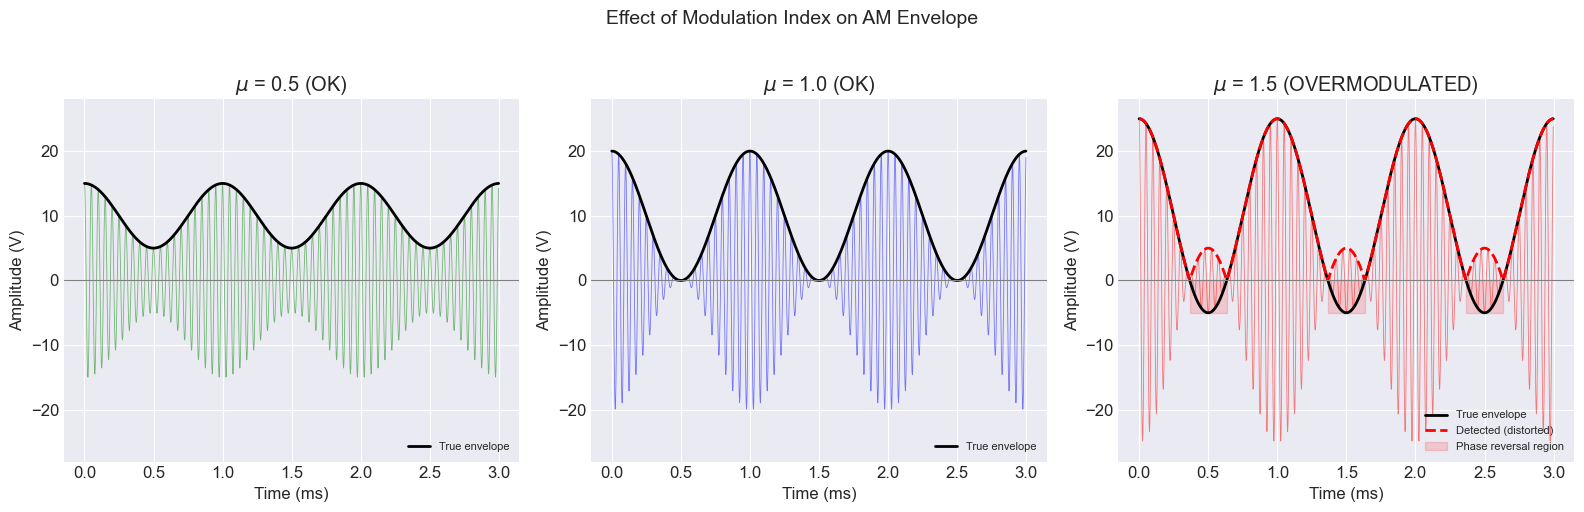

Overmodulation Analysis (μ = 1.5):
  Envelope minimum: Ac(1 - μ) = 10(1 - 1.5) = -5.0 V (negative!)
  Phase reversal occurs when 1 + μ·mn(t) < 0
  → cos(2πfmt) < -1/μ = -0.667
  Envelope detector outputs |envelope| → distorted message recovery


In [4]:
# =============================================================================
# Section 3: Overmodulation — μ = 0.5, 1.0, 1.5
# =============================================================================
fm = 1000
fc = 20000     # Use lower fc for clearer time-domain visualization
Ac = 10
fs_plot = 20 * fc
T = 0.003
t = np.linspace(0, T, int(fs_plot * T), endpoint=False)

mu_values = [0.5, 1.0, 1.5]
colors = ['green', 'blue', 'red']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (mu, color) in enumerate(zip(mu_values, colors)):
    m_n = np.cos(2 * np.pi * fm * t)
    envelope_true = Ac * (1 + mu * m_n)
    s_am = envelope_true * np.cos(2 * np.pi * fc * t)

    # What an envelope detector would output (rectified envelope)
    envelope_detected = np.abs(envelope_true)

    axes[i].plot(t * 1000, s_am, color=color, alpha=0.5, linewidth=0.6)
    axes[i].plot(t * 1000, envelope_true, 'k-', linewidth=2, label='True envelope')
    if mu > 1:
        axes[i].plot(t * 1000, envelope_detected, 'r--', linewidth=2,
                     label='Detected (distorted)')
        axes[i].fill_between(t * 1000, 0, -5,
                             where=(envelope_true < 0), alpha=0.15, color='red',
                             label='Phase reversal region')
    axes[i].axhline(y=0, color='gray', linewidth=0.8, linestyle='-')
    axes[i].set_xlabel('Time (ms)')
    axes[i].set_ylabel('Amplitude (V)')
    status = 'OK' if mu <= 1 else 'OVERMODULATED'
    axes[i].set_title(f'$\\mu$ = {mu} ({status})')
    axes[i].set_ylim(-Ac * 2.8, Ac * 2.8)
    axes[i].legend(fontsize=8, loc='lower right')

plt.suptitle('Effect of Modulation Index on AM Envelope', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Spectral distortion from overmodulation (clipped envelope)
print("Overmodulation Analysis (μ = 1.5):")
print(f"  Envelope minimum: Ac(1 - μ) = {Ac}(1 - 1.5) = {Ac*(1-1.5):.1f} V (negative!)")
print(f"  Phase reversal occurs when 1 + μ·mn(t) < 0")
print(f"  → cos(2πfmt) < -1/μ = -{1/1.5:.3f}")
print(f"  Envelope detector outputs |envelope| → distorted message recovery")

## 4. Envelope Detection

The envelope detector is the simplest AM demodulator — just a diode, resistor, and capacitor.

**Operation:**
1. Diode half-wave rectifies the AM signal
2. RC circuit smooths the rectified signal to follow the envelope
3. DC blocking capacitor removes the DC offset
4. Output ≈ $\mu \cdot m_n(t)$ (the original message)

**RC time constant design constraint:**

$$\frac{1}{f_c} \ll RC \ll \frac{1}{f_{m,\text{max}}}$$

- Too small → carrier ripple (inadequate smoothing)
- Too large → cannot follow fast envelope changes (diagonal clipping)

**Worked Example 4:** AM broadcast at $f_c = 540$ kHz, message BW = 5 kHz
- Need: $1.85\;\mu\text{s} \ll RC \ll 200\;\mu\text{s}$
- Choose: $C = 0.01\;\mu\text{F}$, $R = 10\;\text{k}\Omega$ → $RC = 100\;\mu\text{s}$ ✓

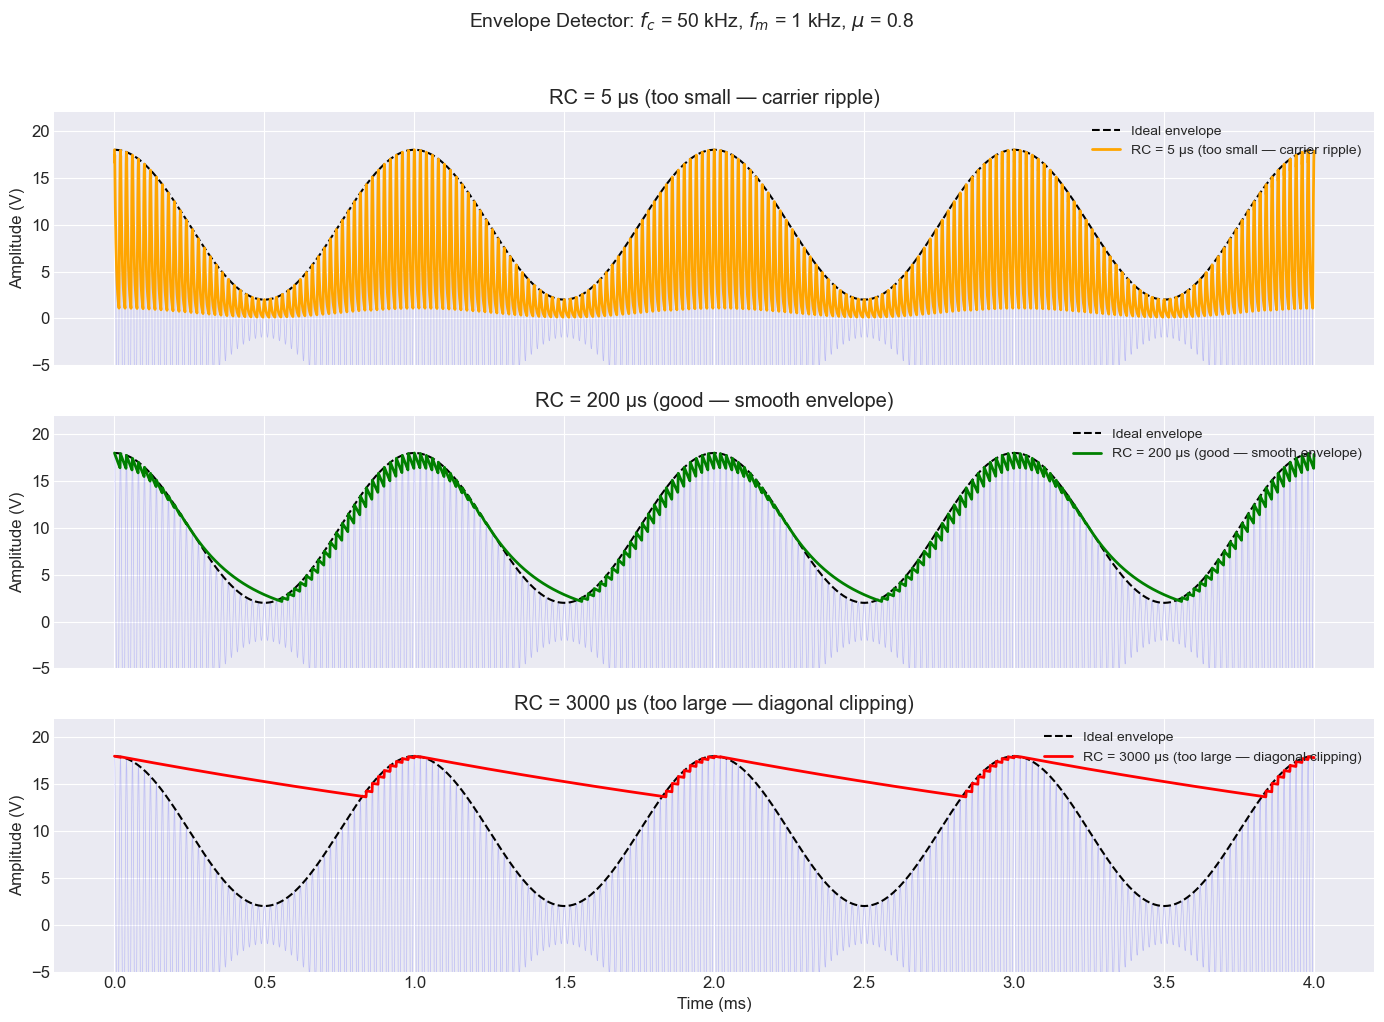

Envelope Detector Design:
  Carrier: fc = 50 kHz → 1/fc = 20 μs
  Message BW: fm = 1 kHz → 1/fm = 1000 μs
  Constraint: 20 μs ≪ RC ≪ 1000 μs
  RC = 5 μs:    < 1/fc = 20 μs → capacitor discharges between carrier peaks
  RC = 200 μs:  10×(1/fc), 0.2×(1/fm) → satisfies both bounds ✓
  RC = 3000 μs: 3×(1/fm) → cannot follow envelope → diagonal clipping


In [5]:
# =============================================================================
# Section 4: Envelope Detector Simulation
# =============================================================================
# Simulate envelope detection with different RC time constants
fm = 1000       # Message frequency
fc = 50000      # Carrier (use 50 kHz for visualization)
Ac = 10
mu = 0.8
fs = 50 * fc
T = 0.004       # 4 ms
t = np.linspace(0, T, int(fs * T), endpoint=False)
dt = t[1] - t[0]

# Generate AM signal
m_n = np.cos(2 * np.pi * fm * t)
s_am = Ac * (1 + mu * m_n) * np.cos(2 * np.pi * fc * t)
envelope_ideal = Ac * (1 + mu * m_n)

# Half-wave rectification (diode)
s_rectified = np.maximum(s_am, 0)

# RC values chosen to demonstrate three regimes:
#   1/fc = 20 μs,  1/fm = 1000 μs
#   Need: 20 μs ≪ RC ≪ 1000 μs
RC_values = [5e-6, 200e-6, 3000e-6]
labels = ['RC = 5 μs (too small — carrier ripple)',
          'RC = 200 μs (good — smooth envelope)',
          'RC = 3000 μs (too large — diagonal clipping)']
colors = ['orange', 'green', 'red']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, (RC, label, color) in enumerate(zip(RC_values, labels, colors)):
    alpha = dt / (RC + dt)
    y = np.zeros_like(s_rectified)
    y[0] = s_rectified[0]
    for n in range(1, len(y)):
        # Diode only charges: output follows input up, decays through RC down
        if s_rectified[n] > y[n - 1]:
            y[n] = s_rectified[n]
        else:
            y[n] = y[n - 1] * (1 - alpha)

    axes[i].plot(t * 1000, s_am, 'b-', alpha=0.2, linewidth=0.5)
    axes[i].plot(t * 1000, envelope_ideal, 'k--', linewidth=1.5, label='Ideal envelope')
    axes[i].plot(t * 1000, y, color=color, linewidth=2, label=label)
    axes[i].set_ylabel('Amplitude (V)')
    axes[i].set_title(label)
    axes[i].legend(fontsize=10, loc='upper right')
    axes[i].set_ylim(-5, Ac * 2.2)

axes[2].set_xlabel('Time (ms)')
plt.suptitle(f'Envelope Detector: $f_c$ = {fc/1000:.0f} kHz, $f_m$ = {fm/1000:.0f} kHz, $\\mu$ = {mu}',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Envelope Detector Design:")
print(f"  Carrier: fc = {fc/1000:.0f} kHz → 1/fc = {1e6/fc:.0f} μs")
print(f"  Message BW: fm = {fm/1000:.0f} kHz → 1/fm = {1e6/fm:.0f} μs")
print(f"  Constraint: {1e6/fc:.0f} μs ≪ RC ≪ {1e6/fm:.0f} μs")
print(f"  RC = 5 μs:    < 1/fc = 20 μs → capacitor discharges between carrier peaks")
print(f"  RC = 200 μs:  10×(1/fc), 0.2×(1/fm) → satisfies both bounds ✓")
print(f"  RC = 3000 μs: 3×(1/fm) → cannot follow envelope → diagonal clipping")

## 5. Power and Efficiency Analysis

**DSB-SC power** (all power carries information):

$$P_{\text{DSB-SC}} = \frac{A_c^2}{2} P_m, \qquad \eta = 100\%$$

**Full AM power** (for single-tone $m_n(t) = \cos(2\pi f_m t)$):

| Component | Expression | Value |
|-----------|-----------|-------|
| Carrier power | $P_c = A_c^2 / 2$ | Carries **no** information |
| Sideband power | $P_{sb} = A_c^2 \mu^2 / 4$ | Carries the message |
| Total power | $P_{total} = P_c + P_{sb} = \frac{A_c^2}{2}\left(1 + \frac{\mu^2}{2}\right)$ | |

**Efficiency:**

$$\eta = \frac{P_{sb}}{P_{total}} = \frac{\mu^2}{2 + \mu^2}$$

- $\mu = 1.0$: $\eta = 1/3 = 33.3\%$ (best case)
- $\mu = 0.5$: $\eta = 1/9 = 11.1\%$

**Trade-off:** Full AM wastes most power in the carrier, but enables simple, cheap envelope detection.

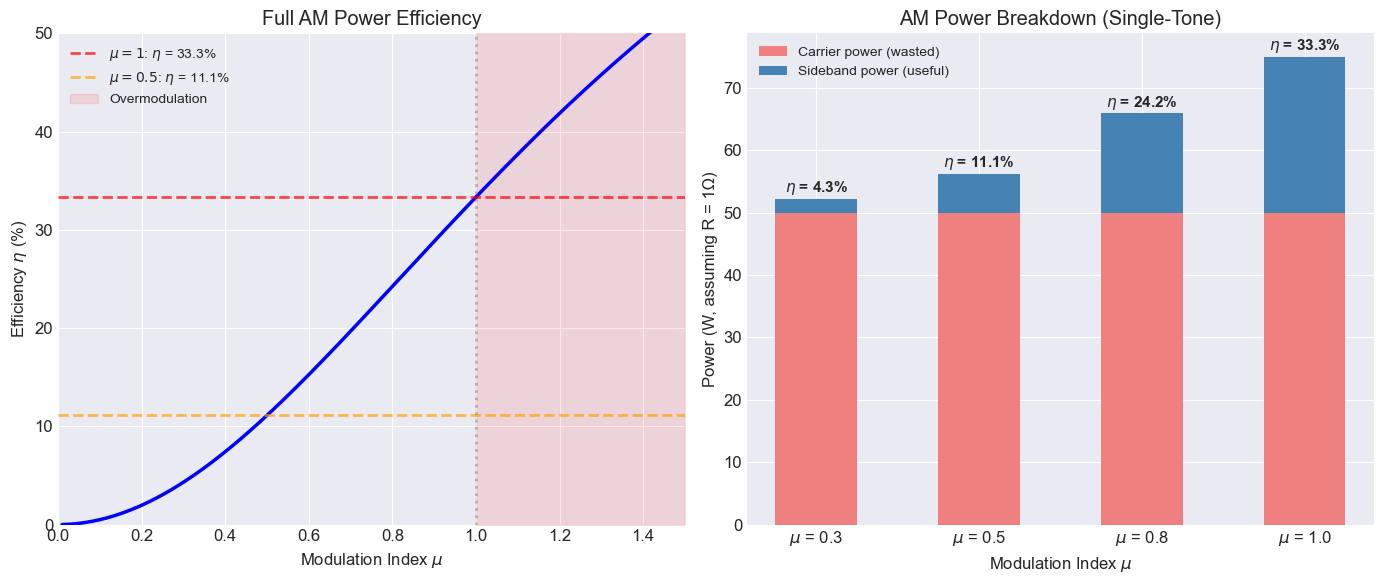

AM Power Efficiency Summary (Ac = 10 V, single-tone modulation):
     μ    P_carrier   P_sideband      P_total   Efficiency
--------------------------------------------------------
   0.3       50.0 W       2.25 W      52.25 W        4.3%
   0.5       50.0 W       6.25 W      56.25 W       11.1%
   0.8       50.0 W      16.00 W      66.00 W       24.2%
   1.0       50.0 W      25.00 W      75.00 W       33.3%

DSB-SC: η = 100% (no carrier component)
Full AM: η ≤ 33.3% — most power wasted in the carrier!


In [6]:
# =============================================================================
# Section 5: Power and Efficiency — DSB-SC vs Full AM
# =============================================================================
Ac = 10  # Carrier amplitude (V)

# Efficiency vs modulation index
mu_range = np.linspace(0.01, 1.5, 200)
eta = mu_range**2 / (2 + mu_range**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Efficiency curve
ax1.plot(mu_range, eta * 100, 'b-', linewidth=2.5)
ax1.axhline(y=100/3, color='r', linestyle='--', alpha=0.7,
            label=f'$\\mu=1$: $\\eta$ = {100/3:.1f}%')
ax1.axhline(y=100/9, color='orange', linestyle='--', alpha=0.7,
            label=f'$\\mu=0.5$: $\\eta$ = {100/9:.1f}%')
ax1.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5)
ax1.fill_betweenx([0, 50], 1.0, 1.5, alpha=0.1, color='red', label='Overmodulation')
ax1.set_xlabel('Modulation Index $\\mu$')
ax1.set_ylabel('Efficiency $\\eta$ (%)')
ax1.set_title('Full AM Power Efficiency')
ax1.legend(fontsize=10)
ax1.set_xlim(0, 1.5)
ax1.set_ylim(0, 50)

# Right: Power breakdown (stacked bar chart)
mu_vals = [0.3, 0.5, 0.8, 1.0]
P_carrier = [Ac**2 / 2] * len(mu_vals)  # Always the same
P_sideband = [Ac**2 * mu**2 / 4 for mu in mu_vals]
P_total = [pc + ps for pc, ps in zip(P_carrier, P_sideband)]
eff = [ps / pt * 100 for ps, pt in zip(P_sideband, P_total)]

x = np.arange(len(mu_vals))
width = 0.5
bars1 = ax2.bar(x, P_carrier, width, label='Carrier power (wasted)', color='lightcoral')
bars2 = ax2.bar(x, P_sideband, width, bottom=P_carrier, label='Sideband power (useful)', color='steelblue')

# Add efficiency labels
for j, (xi, pt, e) in enumerate(zip(x, P_total, eff)):
    ax2.text(xi, pt + 1, f'$\\eta$ = {e:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax2.set_xlabel('Modulation Index $\\mu$')
ax2.set_ylabel('Power (W, assuming R = 1Ω)')
ax2.set_title('AM Power Breakdown (Single-Tone)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'$\\mu$ = {mu}' for mu in mu_vals])
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Comparison table
print("AM Power Efficiency Summary (Ac = 10 V, single-tone modulation):")
print(f"{'μ':>6} {'P_carrier':>12} {'P_sideband':>12} {'P_total':>12} {'Efficiency':>12}")
print("-" * 56)
for mu in mu_vals:
    Pc = Ac**2 / 2
    Ps = Ac**2 * mu**2 / 4
    Pt = Pc + Ps
    e = Ps / Pt * 100
    print(f"{mu:>6.1f} {Pc:>10.1f} W {Ps:>10.2f} W {Pt:>10.2f} W {e:>10.1f}%")
print()
print("DSB-SC: η = 100% (no carrier component)")
print("Full AM: η ≤ 33.3% — most power wasted in the carrier!")

## Summary

### Key Formulas

| Modulation | Signal | Bandwidth | Demodulation | Efficiency |
|-----------|--------|-----------|-------------|------------|
| DSB-SC | $s(t) = m(t) \cdot A_c \cos(2\pi f_c t)$ | $2B$ | Coherent (complex) | 100% |
| Full AM | $s(t) = A_c[1 + \mu \, m_n(t)] \cos(2\pi f_c t)$ | $2B$ | Envelope (simple) | $\leq 33.3\%$ |

### AM Power (single-tone modulation)

| Component | Expression |
|-----------|-----------|
| Carrier power | $P_c = A_c^2 / 2$ |
| Sideband power | $P_{sb} = A_c^2 \mu^2 / 4$ |
| Total power | $P_{total} = \frac{A_c^2}{2}\left(1 + \frac{\mu^2}{2}\right)$ |
| Efficiency | $\eta = \frac{\mu^2}{2 + \mu^2}$ |

### Key Takeaways

1. **Modulation** shifts baseband signals to RF for practical antenna sizes and frequency multiplexing
2. **DSB-SC** is power-efficient (100%) but requires coherent demodulation
3. **Full AM** wastes power in the carrier ($\leq 33.3\%$ efficient) but enables simple envelope detection
4. **Modulation index** $\mu \leq 1$ prevents overmodulation and envelope detector distortion
5. **Envelope detector** RC constraint: $1/f_c \ll RC \ll 1/f_{m,\text{max}}$